# CTA Trend-Following Strategy: Rule-Based Signals + ML Direction Overlay


**Universe:** BTC-USD, ETH-USD, and a handful of liquid large-cap crypto assets (see Part 0 for the exact list) · **Method:** dual-EMA/RSI trend rule tuned via Bayesian optimisation, benchmarked against a logistic-regression direction classifier and a rule+ML hybrid · **Evaluation:** strict 70/30 time-based train/test split, Sharpe/Sortino/Calmar and drawdown metrics reported out-of-sample only.

> Research notebook for educational purposes only — not investment advice. See [Disclaimer](#disclaimer) at the bottom.


## Objective

This notebook builds a fully automated research pipeline for evaluating a **rule‑based CTA trend strategy** and an **ML‑driven direction predictor** across a mixed universe of assets. The core objective is to answer a simple question in a disciplined way: *can a transparent, EMA/RSI‑based CTA rule comprising of Bayesian Optimisation and a lightweight logistic regression model, separately and together, deliver robust risk‑adjusted performance versus buy‑and‑hold?*

The workflow is deliberately modular and reproducible:

- **Part 1–2: Data, risk, and seasonality diagnostics**  
  Download since‑inception OHLCV data from Yahoo Finance, build inception summaries, and run volatility/seasonality analysis (return distributions, rolling realised vol, exp‑weighted monthly seasonality) to understand each asset’s empirical risk regime before modelling.  

- **Part 3–4: CTA signal generation and backtest evaluation**  
  Implement a dual‑EMA + RSI CTA rule, enforce a 70/30 time‑based train/test split, and use Bayesian optimisation to tune the RSI entry threshold on the train window. Evaluate out‑of‑sample performance with equity curves, drawdowns, and full risk–return metrics versus buy‑and‑hold.  

- **Part 5–6: ML direction predictor and hybrid ensemble**  
  Train a logistic regression model on simple price‑derived features to predict next‑day direction, compare its behaviour to the CTA rule, and construct a hybrid ensemble that only acts when both agree. Benchmark all four approaches (ML, CTA, hybrid, buy‑and‑hold) using Sharpe and other diagnostics.

The guiding ethos is **clarity over complexity**: every component is intentionally simple, auditable, and aligned with good research practice (no look‑ahead bias, explicit train/test separation, and transparent hyperparameter tuning at the start of the code).

## Part 0 — Environment Setup & Global Configuration

- Initializes the notebook environment, installs required packages, and imports core libraries for data handling, visualization, machine learning, and report generation.  
- Defines the crypto asset universe, global constants (date range, train/test split, annualization factor, rolling windows, indicator lengths), and a consistent color palette for charts.  
- Implements reusable helper functions for technical indicators (EMA, RSI), portfolio analytics (equity curve, drawdowns, rolling Sharpe), and feature construction to support downstream modelling and backtesting.  
- Sets up figure-saving utilities and a Bayesian optimization routine to tune RSI entry thresholds, along with a corresponding execution function for applying the optimized strategy across the dataset.  

In [1]:
# Global setup
%matplotlib inline
%pip install bayesian-optimization
import os
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import yfinance as yf
from IPython.display import display

from bayes_opt import BayesianOptimization
from scipy.stats import norm, skew, kurtosis, gaussian_kde

# Force interactive mode to stay active for inline rendering
plt.ion()

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_RIGHT
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    HRFlowable, PageBreak, Image, KeepTogether,
)

try:
    from PIL import Image as PILImage
except ImportError:
    pass

warnings.filterwarnings("ignore")

OUTPUT_DIR = "Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# DEFINE ASSETS HERE
# ------------------------------------------------------------------------------
TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "BNB-USD"] # Add or remove assets, e.g. "BTC-USD"
LABELS = [t.replace("-USD", "") for t in TICKERS]
SAFE_ASSETS = [t.replace("-", "_") for t in TICKERS]

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0EA5E9", "#EA580C", "#14B8A6"]
if len(TICKERS) > len(PALETTE):
    import matplotlib.cm as cm_mpl
    PALETTE.extend([mcolors.to_hex(c) for c in cm_mpl.tab20.colors])

START_DATE = "2000-01-01"
TRAIN_RATIO = 0.70
INITIAL_CAP = 10000.0
ANNUALIZATION = 365
ROLL_WINDOW = 30
EW_HALFLIFE_YEARS = 3
DIST_XLIM = (-0.45, 0.45)

FAST_EMA = 20
SLOW_EMA = 60
RSI_LEN = 14
RSI_ENTRY = 50
RSI_EXIT = 40
ROLL_SR_WIN = 180

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# ------------------------------------------------------------------------------
# GLOBAL HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def rsi(series, length=14):
    delta = series.diff()
    gain = delta.clip(lower=0).ewm(alpha=1/length, adjust=False).mean()
    loss = -delta.clip(upper=0).ewm(alpha=1/length, adjust=False).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

def equity_curve(returns, initial=INITIAL_CAP):
    r = pd.Series(returns).fillna(0)
    return initial * (1 + r).cumprod()

def drawdown(equity):
    eq = pd.Series(equity)
    return eq / eq.cummax() - 1

def rolling_sharpe(returns, window=ROLL_SR_WIN, annual=ANNUALIZATION):
    r = pd.Series(returns).fillna(0)
    mu = r.rolling(window).mean() * annual
    sd = r.rolling(window).std() * np.sqrt(annual)
    return mu / sd

def max_drawdown(equity_series):
    dd = equity_series / equity_series.cummax() - 1
    return dd, dd.min()

def longest_drawdown_days(equity_series):
    underwater = (equity_series < equity_series.cummax())
    count, best = 0, 0
    for v in underwater:
        count = count + 1 if v else 0
        best  = max(best, count)
    return best

def build_features(close):
    df = pd.DataFrame({"Close": close})
    df["Mom5"]     = close.pct_change(5)
    df["Mom20"]    = close.pct_change(20)
    df["RSI14"]    = rsi(close, 14)
    df["EMARatio"] = close / close.ewm(span=20, adjust=False).mean()
    df["RealVol"]  = close.pct_change().rolling(20).std() * np.sqrt(ANNUALIZATION)
    df["Target"]   = (close.pct_change().shift(-1) > 0).astype(int)
    return df.dropna()

def save_fig(fig, name):
    path = f"{OUTPUT_DIR}/{name}"
    fig.savefig(path, bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close(fig)

def get_bayes_metrics(train_df, verbose=False):
    """Bayesian Optimization to tune RSI entry threshold (Fair Comparison)."""
    def objective(rsi_entry):
        # Use identical indicators to your CTA strategy
        EMA_Fast = ema(train_df["Close"], FAST_EMA)
        EMA_Slow = ema(train_df["Close"], SLOW_EMA)
        RSI      = rsi(train_df["Close"], RSI_LEN)
        
        long_cond = (EMA_Fast > EMA_Slow) & (RSI > rsi_entry)
        pos = long_cond.astype(int).shift(1).fillna(0)
        rets = pos * train_df["Close"].pct_change()
        
        sharpe = (rets.mean() / rets.std()) * np.sqrt(ANNUALIZATION)
        return sharpe if not np.isnan(sharpe) else -1
        
    optimizer = BayesianOptimization(f=objective, pbounds={'rsi_entry': (30, 70)}, random_state=42)
    optimizer.maximize(init_points=5, n_iter=10)
    if verbose:
        print("Optimization Results:")
        print(optimizer.max)
    return optimizer.max['params']

def run_bayes_strategy(df, params):
    """Executes using globally defined indicator settings."""
    EMA_Fast = ema(df["Close"], FAST_EMA)
    EMA_Slow = ema(df["Close"], SLOW_EMA)
    RSI      = rsi(df["Close"], RSI_LEN)
    signal   = ((EMA_Fast > EMA_Slow) & (RSI > params['rsi_entry'])).astype(int)
    return signal * df["Close"].pct_change()

Note: you may need to restart the kernel to use updated packages.


/Users/shivanshmittal/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shivanshmittal/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Part 1 — Crypto Data Download & Inception Summary

- Downloads adjusted daily price data for the specified crypto assets from Yahoo Finance, normalises the close-price format for single or multiple tickers, and drops empty rows to create a clean price panel.  
- Computes core since-inception performance statistics per asset, including cumulative return, CAGR, annualised volatility, approximate Sharpe ratio, max drawdown, longest drawdown spell, and best/worst daily returns, and stores them in a summary table exported to CSV.  
- Builds and saves three high-level diagnostic charts: (1) **Growth of $1 since inception** to visualise long-run compounding, (2) **drawdown curves** to show peak-to-trough losses over time, and (3) **90-day rolling annualised volatility** to highlight evolving risk regimes across assets.  
- Persists both the cleaned close-price panel and the summary outputs to the `Output` directory, creating a reproducible “inception snapshot” that anchors the rest of the ML and volatility analysis pipeline.  

[*********************100%***********************]  4 of 4 completed



SINCE-INCEPTION SUMMARY
      Ticker Inception Date Latest Date Start Price Latest Price Total Return     CAGR Ann. Volatility Sharpe (approx) Max Drawdown Longest DD (days) Best Day Worst Day
BTC  BTC-USD     2014-09-17  2026-07-03     457.334     61983.09    13453.13%   51.64%          66.55%            0.96      -83.40%              1079   25.25%   -37.17%
ETH  ETH-USD     2017-11-09  2026-07-03     320.884      1741.46      442.71%   21.61%          84.93%            0.66      -93.96%              1382   26.46%   -42.35%
SOL  SOL-USD     2020-04-10  2026-07-03      0.9511        81.55     8474.70%  104.35%         119.46%            1.19      -96.27%              1168   47.28%   -42.28%
BNB  BNB-USD     2017-11-09  2026-07-03      1.9908       566.23    28342.76%   92.23%          95.14%            1.14      -80.10%              1127   69.76%   -41.90%


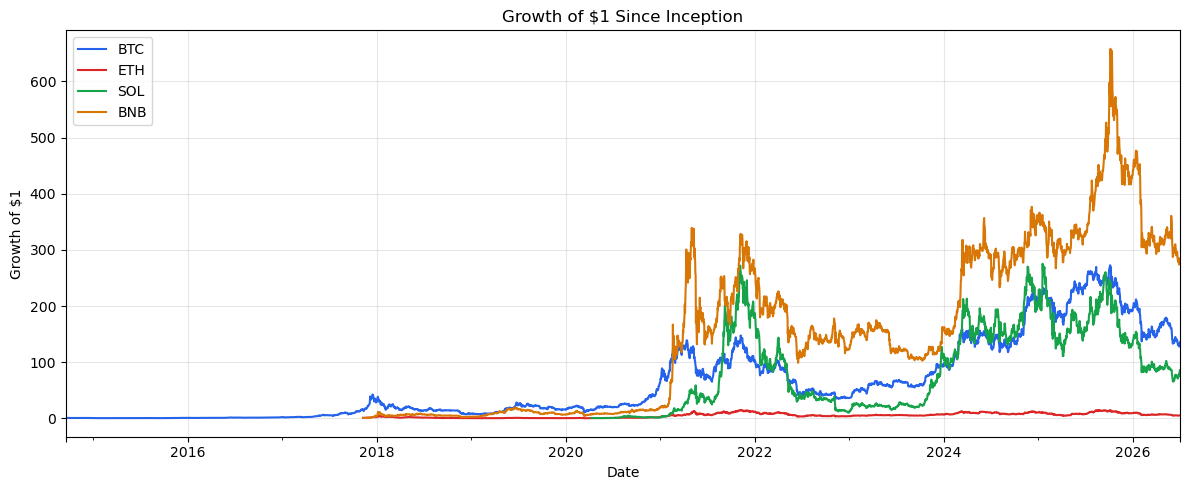

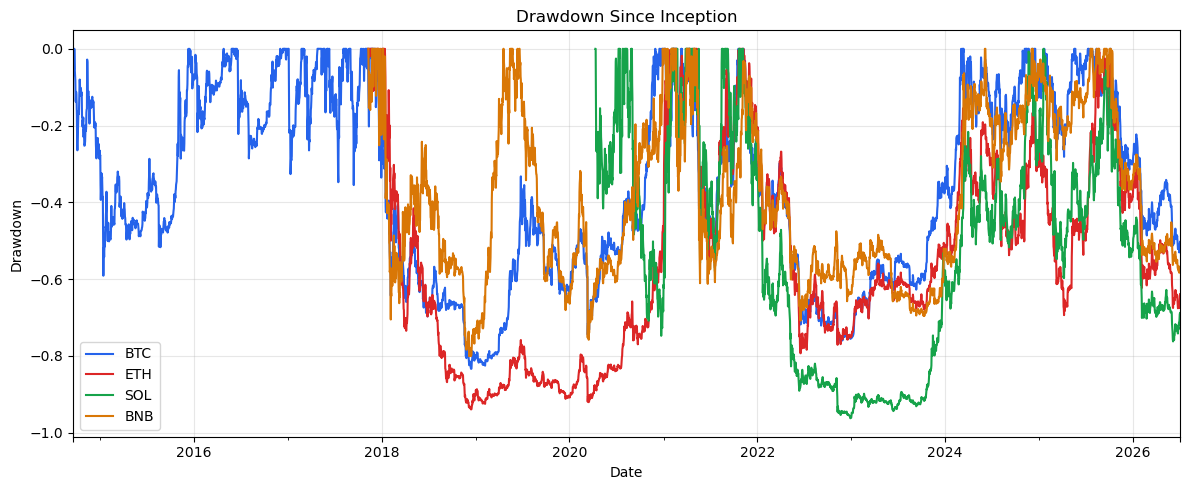

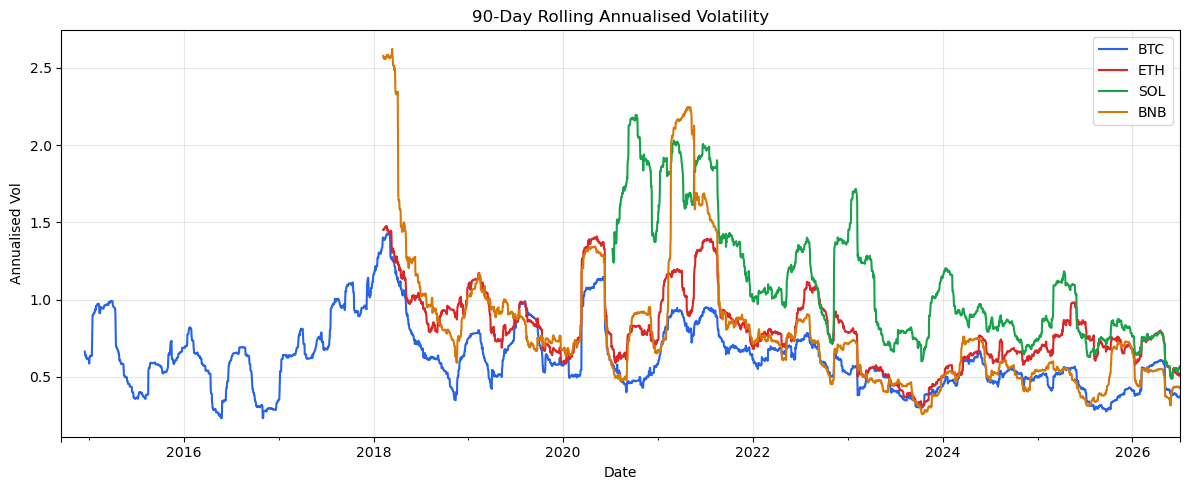

In [2]:
# ==============================================================================
# PART 1: CRYPTO DATA DOWNLOAD & INCEPTION SUMMARY
# ==============================================================================
print("Downloading price data...")
raw_data = yf.download(TICKERS, start=START_DATE, auto_adjust=True, progress=True)

# Parse format cleanly depending on single vs multiple tickers
if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data["Close"]
else:
    data = raw_data[["Close"]].rename(columns={"Close": TICKERS[0]})

data = data.dropna(how="all")

results       = {}
equity_curves = {}
drawdowns     = {}

for ticker, label in zip(TICKERS, LABELS):
    price      = data[ticker].dropna()
    daily_ret  = price.pct_change().dropna()
    equity     = (1 + daily_ret).cumprod()
    dd, mdd    = max_drawdown(equity)

    years      = (price.index[-1] - price.index[0]).days / 365.25
    cagr       = equity.iloc[-1] ** (1 / years) - 1
    ann_vol    = daily_ret.std() * np.sqrt(365)
    ann_ret    = daily_ret.mean() * 365
    sharpe     = ann_ret / ann_vol if ann_vol else np.nan

    equity_curves[label] = equity
    drawdowns[label]     = dd
    results[label] = {
        "Ticker":                ticker,
        "Inception Date":        price.index[0].date(),
        "Latest Date":           price.index[-1].date(),
        "Start Price":           round(price.iloc[0], 4),
        "Latest Price":          round(price.iloc[-1], 2),
        "Total Return":          f"{equity.iloc[-1] - 1:.2%}",
        "CAGR":                  f"{cagr:.2%}",
        "Ann. Volatility":       f"{ann_vol:.2%}",
        "Sharpe (approx)":       f"{sharpe:.2f}",
        "Max Drawdown":          f"{mdd:.2%}",
        "Longest DD (days)":     longest_drawdown_days(equity),
        "Best Day":              f"{daily_ret.max():.2%}",
        "Worst Day":             f"{daily_ret.min():.2%}",
    }

summary = pd.DataFrame(results).T
print("\n" + "=" * 90)
print("SINCE-INCEPTION SUMMARY")
print("=" * 90)
print(summary.to_string())
summary.to_csv(f"{OUTPUT_DIR}/Part1_inception_summary.csv")

# --- CHART 1: Growth of $1 ---
plt.figure(figsize=(12, 5))
for lbl, color in zip(LABELS, PALETTE):
    equity_curves[lbl].plot(label=lbl, color=color)
plt.title("Growth of $1 Since Inception")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Part1_growth_of_1.png", dpi=150)
plt.show()   # <-- FIX: Renders the Growth Curve plot in your notebook
plt.close()

# --- CHART 2: Drawdown ---
plt.figure(figsize=(12, 5))
for lbl, color in zip(LABELS, PALETTE):
    drawdowns[lbl].plot(label=lbl, color=color)
plt.title("Drawdown Since Inception")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Part1_drawdown.png", dpi=150)
plt.show()   # <-- FIX: Renders the Drawdown plot in your notebook
plt.close()

# --- CHART 3: Rolling Volatility ---
plt.figure(figsize=(12, 5))
for ticker, lbl, color in zip(TICKERS, LABELS, PALETTE):
    rv = data[ticker].dropna().pct_change().rolling(90).std() * np.sqrt(365)
    rv.plot(label=lbl, color=color)
plt.title("90-Day Rolling Annualised Volatility")
plt.ylabel("Annualised Vol")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Part1_rolling_vol.png", dpi=150)
plt.show()   # <-- FIX: Renders the Rolling Volatility plot in your notebook
plt.close()

data.to_csv(f"{OUTPUT_DIR}/Part1_close_prices.csv")

## Part 2 — Volatility Analysis

- Computes daily percentage returns for all assets and constructs a 30-day rolling realised volatility series (annualised) to characterise short-horizon risk dynamics.  
- For each asset, generates a return distribution chart combining a histogram of daily returns, a smooth kernel density estimate (KDE), and a fitted normal distribution with matching mean and standard deviation, plus annotated statistics (mean, volatility, skewness, excess kurtosis, best/worst day, sample size).  
- Builds a seasonality heatmap per asset by estimating exponentially weighted average monthly returns by calendar month, using a diverging colour scale to highlight persistently strong/weak months and any recent regime shifts.  
- Produces a cross-asset 30-day rolling realised volatility overlay, plotting all assets’ rolling vol series on a single chart to reveal volatility clustering, relative risk levels, and co-movements, and exports a consolidated volatility summary table for downstream analysis and reporting.  


Generating return distribution charts...


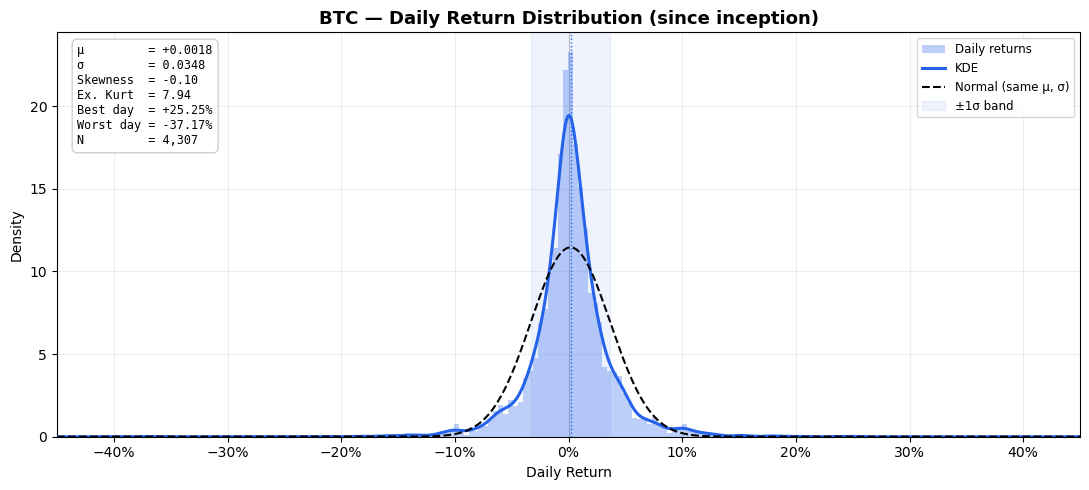

  BTC: inception=2014-09-18  N=4,307  skew=-0.10  ex.kurt=7.9


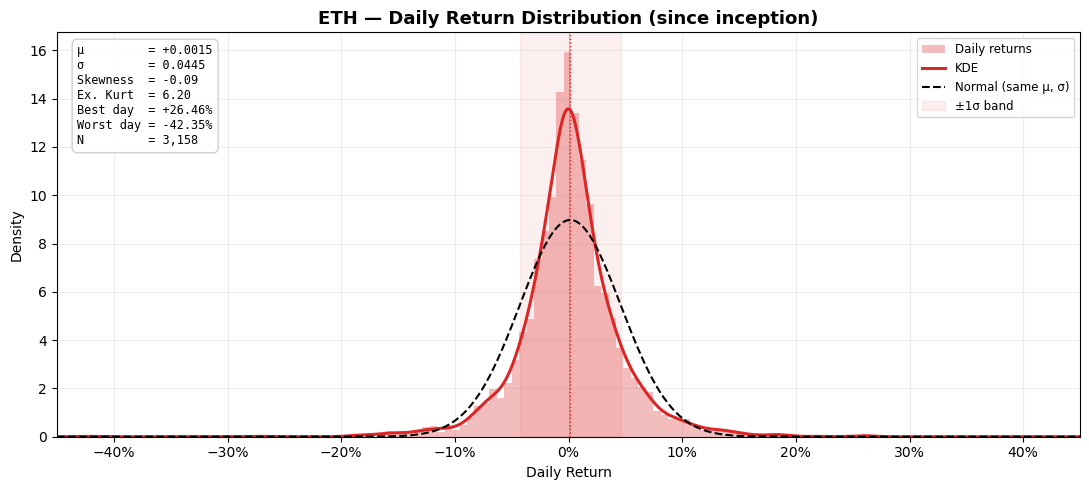

  ETH: inception=2017-11-10  N=3,158  skew=-0.09  ex.kurt=6.2


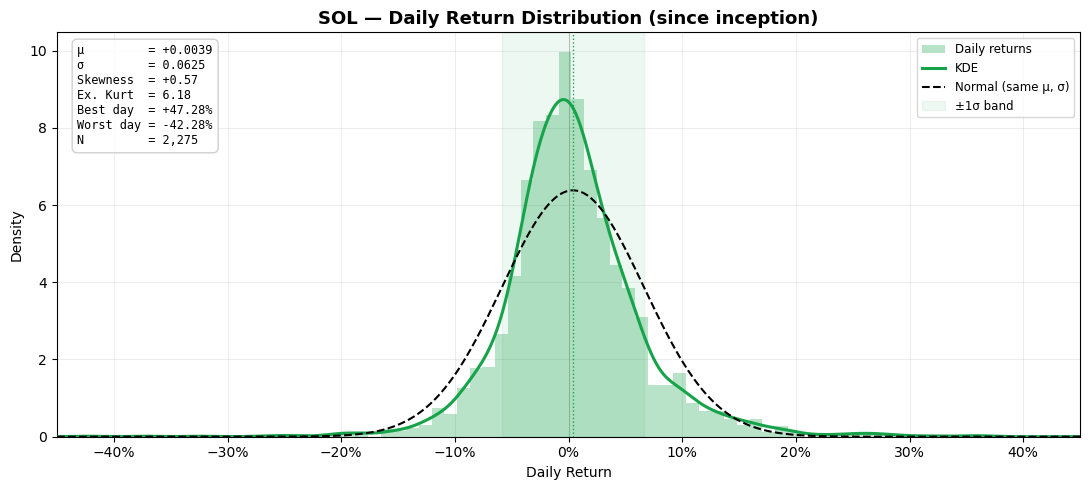

  SOL: inception=2020-04-11  N=2,275  skew=+0.57  ex.kurt=6.2


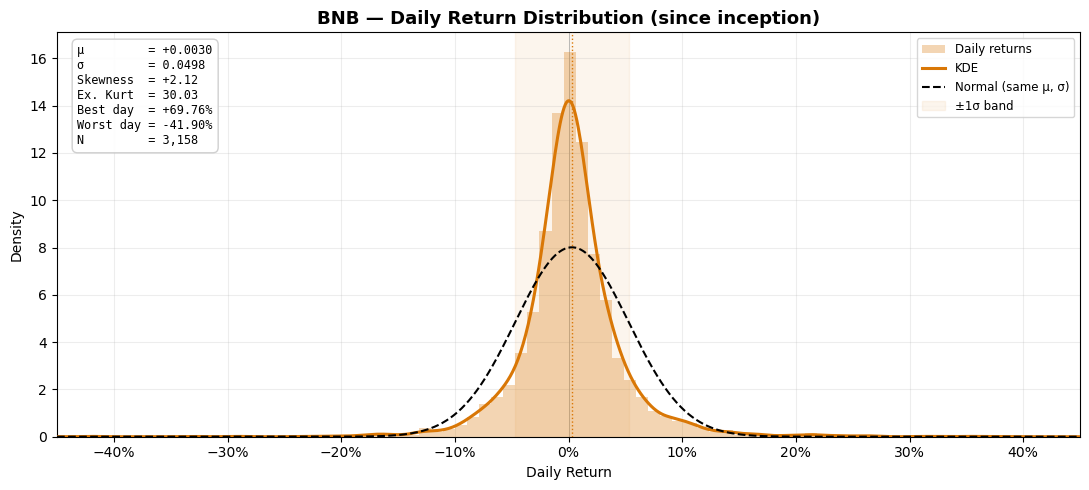

  BNB: inception=2017-11-10  N=3,158  skew=+2.12  ex.kurt=30.0

Generating seasonality heatmaps...
  BTC: best month=Oct  worst month=Jun
  ETH: best month=Jul  worst month=Jun
  SOL: best month=Aug  worst month=Jun
  BNB: best month=Feb  worst month=Jun


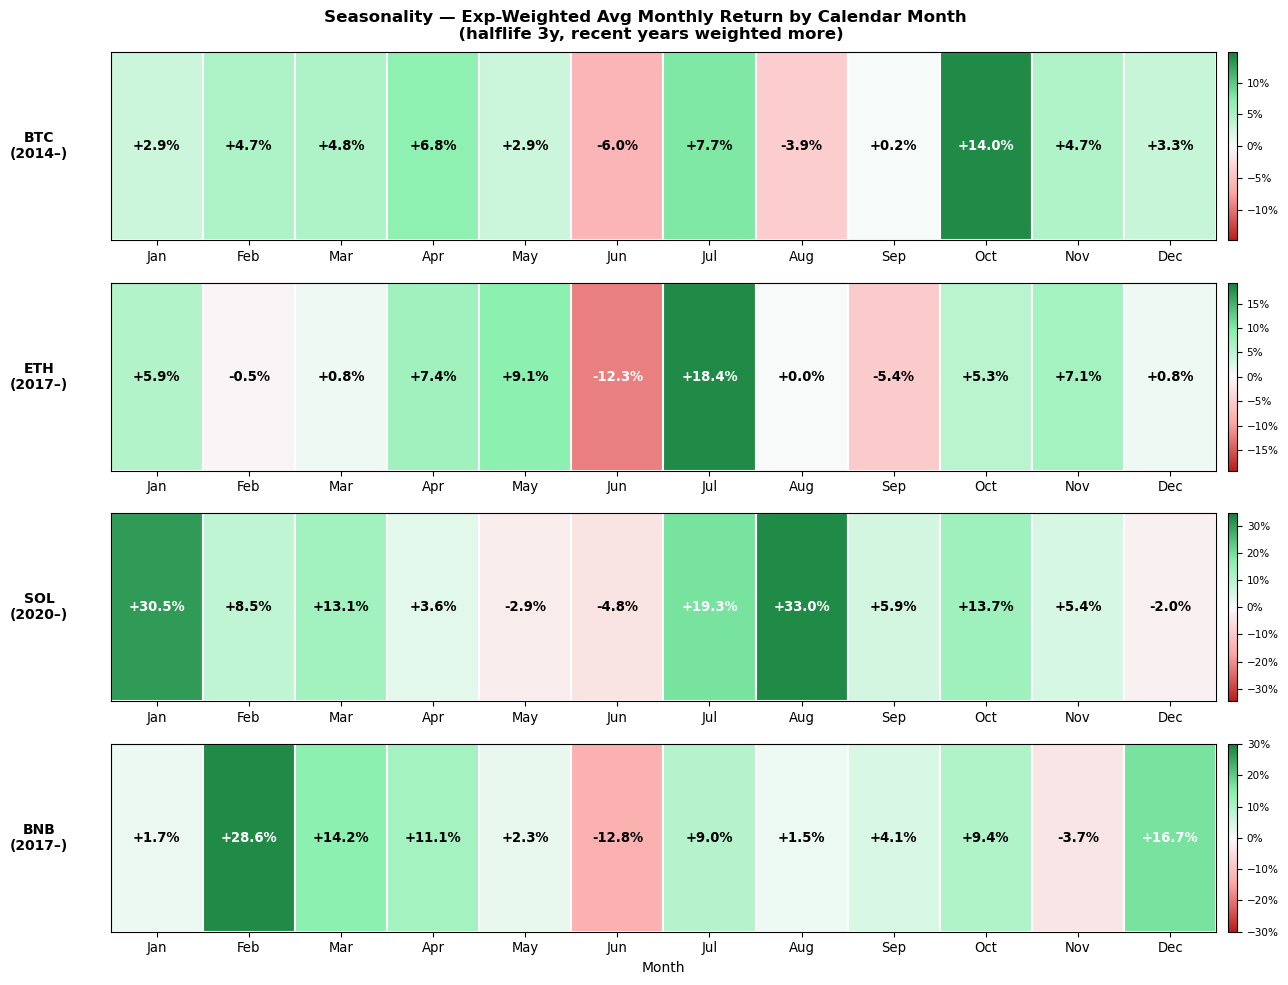


Generating cross-asset vol overlay...


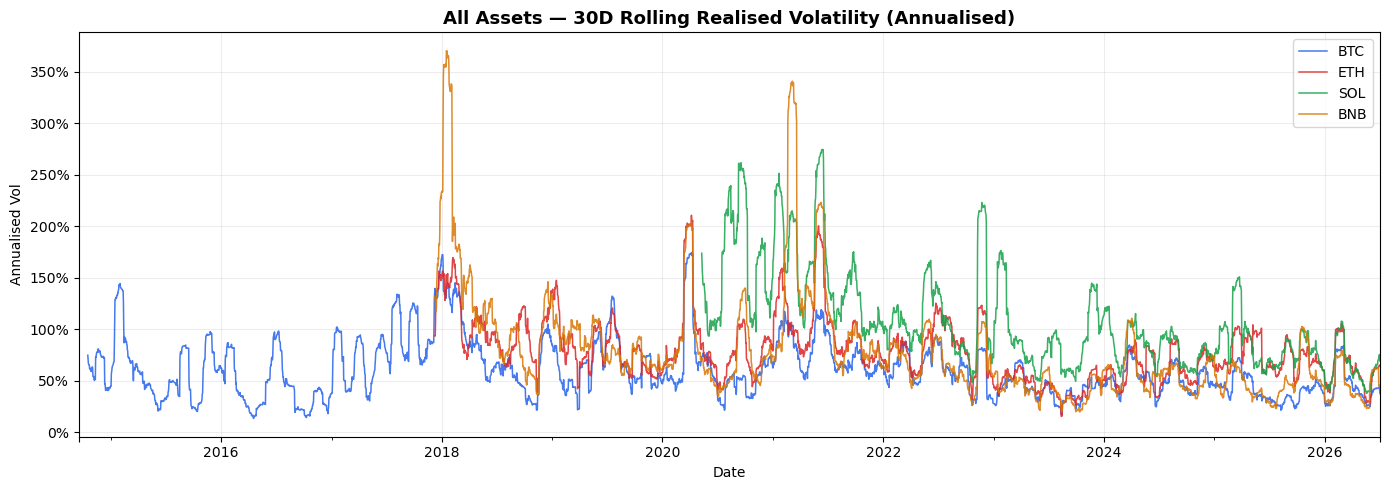


VOLATILITY SUMMARY
Asset  Inception  N (days) Mean 30D RV Max 30D RV Skewness Excess Kurtosis Best Day Worst Day Best Month (EW) Worst Month (EW)
  BTC 2014-09-18      4307      60.36%    174.49%   -0.096            7.94  +25.25%   -37.17%             Oct              Jun
  ETH 2017-11-10      3158      78.93%    210.61%   -0.093            6.20  +26.46%   -42.35%             Jul              Jun
  SOL 2020-04-11      2275     107.63%    274.40%   +0.571            6.18  +47.28%   -42.28%             Aug              Jun
  BNB 2017-11-10      3158      78.29%    370.33%   +2.125           30.03  +69.76%   -41.90%             Feb              Jun


In [3]:
# ==============================================================================
# PART 2: VOLATILITY ANALYSIS
# ==============================================================================
print("\nGenerating return distribution charts...")
returns = data.pct_change().dropna(how="all")
rv30    = returns.rolling(ROLL_WINDOW).std() * np.sqrt(ANNUALIZATION)

for ticker, label, color in zip(TICKERS, LABELS, PALETTE):
    r = returns[ticker].dropna()

    mu      = r.mean()
    sigma   = r.std()
    sk      = skew(r)
    kurt_ex = kurtosis(r, fisher=True)
    best    = r.max()
    worst   = r.min()

    fig, ax = plt.subplots(figsize=(11, 5))

    n_bins = min(250, max(80, len(r) // 30))
    ax.hist(r, bins=n_bins, density=True, color=color, alpha=0.30,
            label="Daily returns", zorder=2)

    x_grid = np.linspace(DIST_XLIM[0], DIST_XLIM[1], 800)
    kde_fn = gaussian_kde(r, bw_method="scott")
    ax.plot(x_grid, kde_fn(x_grid), color=color, linewidth=2.2,
            label="KDE", zorder=3)

    ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black",
            linewidth=1.5, linestyle="--", label="Normal (same \u03bc, \u03c3)", zorder=4)

    ax.axvspan(mu - sigma, mu + sigma, alpha=0.07, color=color, label="\u00b11\u03c3 band")
    ax.axvline(mu, color=color, linewidth=1.0, linestyle=":", zorder=5)
    ax.axvline(0,  color="grey", linewidth=0.7, linestyle="-", alpha=0.5, zorder=1)

    stats_text = (
        f"\u03bc         = {mu:+.4f}\n"
        f"\u03c3         = {sigma:.4f}\n"
        f"Skewness  = {sk:+.2f}\n"
        f"Ex. Kurt  = {kurt_ex:.2f}\n"
        f"Best day  = {best:+.2%}\n"
        f"Worst day = {worst:+.2%}\n"
        f"N         = {len(r):,}"
    )
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
            fontsize=8.5, verticalalignment="top", horizontalalignment="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor="#cccccc", alpha=0.92))

    ax.legend(fontsize=8.5, loc="upper right")
    ax.set_xlim(DIST_XLIM)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

    ax.set_title(f"{label} — Daily Return Distribution (since inception)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.22)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/Part2_{label}_return_distribution.png", dpi=150)
    
    # --- FIX: Show the distribution plot inline before closing ---
    plt.show()
    plt.close(fig)
    
    print(f"  {label}: inception={r.index.min().date()}  N={len(r):,}  skew={sk:+.2f}  ex.kurt={kurt_ex:.1f}")

print("\nGenerating seasonality heatmaps...")

def ew_monthly_avg(ret_series, halflife_years=EW_HALFLIFE_YEARS):
    monthly_ret = (1 + ret_series).resample("ME").prod() - 1
    monthly_ret.index = monthly_ret.index.to_period("M")

    res = {}
    most_recent_year = monthly_ret.index.year.max()

    for mo in range(1, 13):
        mo_data = monthly_ret[monthly_ret.index.month == mo]
        if mo_data.empty:
            res[mo] = np.nan
            continue
        years   = mo_data.index.year.values
        vals    = mo_data.values
        years_ago = most_recent_year - years
        weights   = np.exp(-np.log(2) * years_ago / halflife_years)
        res[mo] = np.average(vals, weights=weights)
    return res

cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "rg_div",
    ["#b91c1c", "#fca5a5", "#f9fafb", "#86efac", "#15803d"],
    N=256
)

months = list(range(1, 13))
fig, axes = plt.subplots(len(LABELS), 1, figsize=(13, 2.5 * len(LABELS)))

# Safety layout adjustment if processing only 1 asset
if len(LABELS) == 1:
    axes = [axes]
    
fig.suptitle(
    f"Seasonality — Exp-Weighted Avg Monthly Return by Calendar Month\n"
    f"  (halflife {EW_HALFLIFE_YEARS}y, recent years weighted more)",
    fontsize=12, fontweight="bold"
)

for ax, ticker, label, color in zip(axes, TICKERS, LABELS, PALETTE):
    r      = returns[ticker].dropna()
    ew_avg = ew_monthly_avg(r)
    values = np.array([ew_avg.get(m, np.nan) for m in months])
    vabs   = np.nanmax(np.abs(values)) * 1.05

    for c_i, (mo, val) in enumerate(zip(months, values)):
        face = "#eeeeee" if np.isnan(val) else cmap_div((val + vabs) / (2 * vabs))
        ax.add_patch(plt.Rectangle([c_i - 0.5, -0.5], 1, 1,
                                   facecolor=face, edgecolor="white", linewidth=1.5))
        if not np.isnan(val):
            txt_color = "white" if abs(val) > vabs * 0.55 else "black"
            ax.text(c_i, 0, f"{val:+.1%}", ha="center", va="center",
                    fontsize=9.5, fontweight="bold", color=txt_color)

    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_LABELS, fontsize=9.5)
    ax.set_yticks([])
    inception_yr = r.index.min().year
    ax.set_ylabel(f"{label}\n({inception_yr}–)", fontsize=10,
                  fontweight="bold", rotation=0, labelpad=48, va="center")

    sm = plt.cm.ScalarMappable(cmap=cmap_div, norm=mcolors.Normalize(vmin=-vabs, vmax=vabs))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.018, pad=0.01)
    cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    cbar.ax.tick_params(labelsize=7.5)

    print(f"  {label}: best month={MONTH_LABELS[int(np.nanargmax(values))]}  worst month={MONTH_LABELS[int(np.nanargmin(values))]}")

# Use the last axis element safely regardless of shape dimension
if len(LABELS) == 1:
    axes[0].set_xlabel("Month", fontsize=10)
else:
    axes[-1].set_xlabel("Month", fontsize=10)

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/Part2_all_seasonality_heatmap.png", dpi=150, bbox_inches="tight")

# --- FIX: Show the heatmap inline before closing ---
plt.show()
plt.close(fig)

print("\nGenerating cross-asset vol overlay...")
fig, ax = plt.subplots(figsize=(14, 5))
for ticker, label, color in zip(TICKERS, LABELS, PALETTE):
    rv30[ticker].plot(ax=ax, label=label, color=color, linewidth=1.1, alpha=0.85)
ax.set_title("All Assets — 30D Rolling Realised Volatility (Annualised)", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualised Vol")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend()
ax.grid(True, alpha=0.22)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/Part1_cross_asset_rv_overlay.png", dpi=150)

# --- FIX: Show the cross-asset vol overlay inline before closing ---
plt.show()
plt.close(fig)

rows = []
for ticker, label in zip(TICKERS, LABELS):
    r  = returns[ticker].dropna()
    rv = rv30[ticker].dropna()
    ew = ew_monthly_avg(r)
    best_mo  = MONTH_LABELS[max(ew, key=lambda m: ew[m] if not np.isnan(ew[m]) else -999) - 1]
    worst_mo = MONTH_LABELS[min(ew, key=lambda m: ew[m] if not np.isnan(ew[m]) else 999) - 1]
    rows.append({
        "Asset":           label,
        "Inception":       r.index.min().date(),
        "N (days)":        len(r),
        "Mean 30D RV":     f"{rv.mean():.2%}",
        "Max 30D RV":      f"{rv.max():.2%}",
        "Skewness":        f"{skew(r):+.3f}",
        "Excess Kurtosis": f"{kurtosis(r, fisher=True):.2f}",
        "Best Day":        f"{r.max():+.2%}",
        "Worst Day":       f"{r.min():+.2%}",
        "Best Month (EW)": best_mo,
        "Worst Month (EW)":worst_mo,
    })

summary = pd.DataFrame(rows)
summary.to_csv(f"{OUTPUT_DIR}/Part2_vol_summary.csv", index=False)
print("\n" + "=" * 80)
print("VOLATILITY SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))

## Part 3 — CTA Position Generator & Bayesian Pre‑Processing

- Downloads full OHLCV price histories for each crypto asset and constructs a clean, standardised dataset, including EMA- and RSI-based trend/momentum indicators.  
- Implements a deterministic CTA-style position engine that converts indicator signals into long-only position states, explicit entry/exit flags, and an executable (one-bar‑lagged) position series.  
- Applies a time-based train/test split to each asset’s history and runs Bayesian optimisation on the training window to select the RSI entry threshold that maximises an in-sample Sharpe-like objective.  
- Uses the optimised parameters to generate out-of-sample strategy returns on the test set, stores full position and return histories to disk, and builds a compact summary table (per asset and sample) covering trade counts and Bayes-optimised Sharpe for downstream evaluation.  

In [4]:
# ==============================================================================
# PART 3: CTA POSITION GENERATOR & BAYESIAN PRE-PROCESSING
# ==============================================================================
def download_ohlcv(ticker):
    raw = yf.download(ticker, start=START_DATE, auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    df = raw[["Open", "High", "Low", "Close", "Volume"]].dropna(subset=["Close"])
    print(f"  {ticker}: {df.index.min().date()} \u2192 {df.index.max().date()}  ({len(df):,} rows)")
    return df

def generate_signals(df):
    out = df.copy()
    out["EMA_Fast"]   = ema(out["Close"], FAST_EMA)
    out["EMA_Slow"]   = ema(out["Close"], SLOW_EMA)
    out["RSI"]        = rsi(out["Close"], RSI_LEN)

    out["Raw_Long"] = (out["EMA_Fast"] > out["EMA_Slow"]) & (out["RSI"] > RSI_ENTRY)
    out["Raw_Exit"] = (out["EMA_Fast"] < out["EMA_Slow"]) | (out["RSI"] < RSI_EXIT)

    position = 0.0
    positions, entries, exits = [], [], []

    for i in range(len(out)):
        long_sig = bool(out["Raw_Long"].iloc[i])
        exit_sig = bool(out["Raw_Exit"].iloc[i])

        if position == 0.0 and long_sig:
            position = 1.0
            entries.append(True); exits.append(False)
        elif position == 1.0 and exit_sig:
            position = 0.0
            entries.append(False); exits.append(True)
        else:
            entries.append(False); exits.append(False)

        positions.append(position)

    out["Position"]      = positions
    out["Entry_Signal"]  = entries
    out["Exit_Signal"]   = exits
    out["Executable_Position"] = out["Position"].shift(1).fillna(0.0)
    return out

def add_split(df):
    n       = len(df)
    split_i = int(n * TRAIN_RATIO)
    df = df.copy()
    df["Sample"] = "TEST"
    df.iloc[:split_i, df.columns.get_loc("Sample")] = "TRAIN"
    return df, df.index[split_i]

print("\n" + "=" * 80)
# Ensure the global dictionary exists
market_frames = {} 

print("\n" + "=" * 80)
print("CTA POSITION GENERATOR & BAYESIAN OPTIMIZATION")
print("=" * 80)

summary_rows = []

for ticker, safe_asset in zip(TICKERS, SAFE_ASSETS):
    # 1. Download & Signal Generation
    raw_ohlcv = download_ohlcv(ticker)
    df = generate_signals(raw_ohlcv)
    df, split_date = add_split(df)
    
    # Store in memory for all future parts
    market_frames[ticker] = df 

    # 2. Run Bayesian Optimization (using the Training split)
    train_df = df[df["Sample"] == "TRAIN"].copy()
    test_df = df[df["Sample"] == "TEST"].copy()
    
    print(f"  Optimizing Bayes params for {ticker}...")
    best_params = get_bayes_metrics(train_df)
    
    # 3. Generate Bayes Strategy Returns (and store in the dataframe)
    bayes_rets = run_bayes_strategy(test_df, best_params)
    df.loc[df["Sample"] == "TEST", "Bayes_Ret"] = bayes_rets

    # 4. Save to disk
    df.to_csv(f"{OUTPUT_DIR}/Part3_{safe_asset}_positions_full.csv")
    
    # 5. Update summary_rows
    for sample in ["TRAIN", "TEST"]:
        block = df[df["Sample"] == sample]
        
        # Calculate Sharpe for summary (if OOS)
        sharpe_val = np.nan
        if sample == "TEST":
            r = block["Bayes_Ret"].fillna(0)
            sharpe_val = (r.mean() / r.std()) * np.sqrt(ANNUALIZATION) if r.std() > 0 else 0

        summary_rows.append({
            "Ticker":       ticker,
            "Sample":       sample,
            "Rows":         len(block),
            "Entries":      int(block["Entry_Signal"].sum()),
            "Exits":        int(block["Exit_Signal"].sum()),
            "Bayes_Sharpe": sharpe_val if not np.isnan(sharpe_val) else 0.0
        })

# Save summary
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{OUTPUT_DIR}/Part3_position_summary.csv", index=False)
print(summary_df.to_string(index=False))



CTA POSITION GENERATOR & BAYESIAN OPTIMIZATION
  BTC-USD: 2014-09-17 → 2026-07-03  (4,308 rows)
  Optimizing Bayes params for BTC-USD...
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 1.2563172 | 44.981604 |
| 2         | 1.5301504 | 68.028572 |
| 3         | 1.6769682 | 59.279757 |
| 4         | 1.6688069 | 53.946339 |
| 5         | 1.3607561 | 36.240745 |
| 6         | 1.3274533 | 30.0      |
| 7         | 1.7553714 | 56.588528 |
| 8         | 1.7533150 | 57.374541 |
| 9         | 1.7691592 | 56.938056 |
| 10        | 1.6513515 | 63.112004 |
| 11        | 1.6677672 | 50.691856 |
| 12        | 1.3062646 | 40.352887 |
| 13        | 1.6453574 | 65.322000 |
| 14        | 1.6869443 | 52.244350 |
| 15        | 1.6780170 | 61.159141 |
  ETH-USD: 2017-11-09 → 2026-07-03  (3,159 rows)
  Optimizing Bayes params for ETH-USD...
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 0.9018810 | 44.981604 |
| 2        

## Part 4 — CTA Backtest Evaluation

- Converts positions into daily strategy and buy‑and‑hold returns, then builds equity curves from a common initial capital to make performance paths directly comparable over time.  
- Computes a comprehensive set of risk–return metrics (total return, CAGR, annualised return and volatility, Sharpe, Sortino, Calmar, max drawdown, and win rate) for each asset and for both the training and out‑of‑sample test windows.  
- Generates and saves diagnostic charts at both full‑sample and split‑sample levels: equity curves, drawdown profiles, and rolling Sharpe ratio plots, with the 70/30 train–test boundary clearly annotated.  
- Aggregates all metrics into a tidy summary table, formats them into presentation‑friendly percentages, and exports the results to CSV for easy inclusion in reports and slide decks.  

In [5]:
# ==============================================================================
# PART 4: BACKTEST EVALUATION — LOGREG / BAYES / HYBRID / BUY & HOLD
# ==============================================================================

def equity(returns):
    return INITIAL_CAP * (1 + pd.Series(returns).fillna(0)).cumprod()


def metrics(returns, label=""):
    r        = pd.Series(returns).fillna(0)
    eq       = equity(r)
    n_years  = len(r) / ANNUALIZATION
    tot_ret  = eq.iloc[-1] / INITIAL_CAP - 1
    cagr     = (eq.iloc[-1] / INITIAL_CAP) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    ann_ret  = r.mean() * ANNUALIZATION
    ann_vol  = r.std()  * np.sqrt(ANNUALIZATION)
    sharpe   = ann_ret / ann_vol if ann_vol else np.nan
    down_vol = r[r < 0].std() * np.sqrt(ANNUALIZATION)
    sortino  = ann_ret / down_vol if down_vol else np.nan
    mdd      = drawdown(eq).min()
    calmar   = cagr / abs(mdd) if mdd else np.nan
    win_rate = (r > 0).sum() / (r != 0).sum() if (r != 0).any() else np.nan

    return {
        "Label":       label,
        "Days":        len(r),
        "Total Return": tot_ret,
        "CAGR":        cagr,
        "Ann. Return": ann_ret,
        "Ann. Vol":    ann_vol,
        "Sharpe":      sharpe,
        "Sortino":     sortino,
        "Calmar":      calmar,
        "Max DD":      mdd,
        "Win Rate":    win_rate,
    }


def save(fig, name):
    path = f"{OUTPUT_DIR}/{name}"
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def line_chart(dates, series_dict, title, ylabel):
    fig, ax = plt.subplots(figsize=(13, 5))
    for lbl, vals in series_dict.items():
        ax.plot(dates, vals, label=lbl, linewidth=1.3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig


## Part 5 — ML Direction Predictor (Logistic Regression + Hybrid Ensemble)

- Builds a supervised learning dataset per asset using engineered technical features (short/medium‑term momentum, RSI, EMA ratio, realised volatility) and a binary next‑day direction target, then applies a 70/30 time‑based split into train and out‑of‑sample test sets.  
- Trains a logistic regression classifier (with feature scaling and class balancing) to predict the sign of next‑day returns, evaluates its probabilistic output (AUC), and converts predictions into a simple long/flat trading rule.  
- Runs the Bayesian‑optimised CTA strategy on the same test window and constructs a hybrid ensemble signal that only goes long when both the ML classifier and the CTA rule agree, then computes corresponding PnL series for ML‑only, CTA‑only, hybrid, and buy‑and‑hold baselines.  
- Generates professional OOS equity and drawdown plots comparing all four approaches and exports a summary table of AUC and Sharpe ratios, along with the full test‑period time series, for downstream analysis and reporting.


ML DIRECTION PREDICTOR — LOGISTIC REGRESSION & HYBRID ENSEMBLE

------------------------------------------------------------
BTC-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 1.2151993 | 44.981604 |
| 2         | 1.4838999 | 68.028572 |
| 3         | 1.6267850 | 59.279757 |
| 4         | 1.6071433 | 53.946339 |
| 5         | 1.3216792 | 36.240745 |
| 6         | 1.2895761 | 30.0      |
| 7         | 1.6838426 | 56.661046 |
| 8         | 1.6932727 | 57.442725 |
| 9         | 1.4982983 | 63.920006 |
| 10        | 1.7086191 | 57.756512 |
| 11        | 1.6258442 | 50.501220 |
| 12        | 1.2544851 | 40.337285 |
| 13        | 1.3195673 | 48.622966 |
| 14        | 1.6111378 | 52.032722 |
| 15        | 1.3319596 | 70.0      |


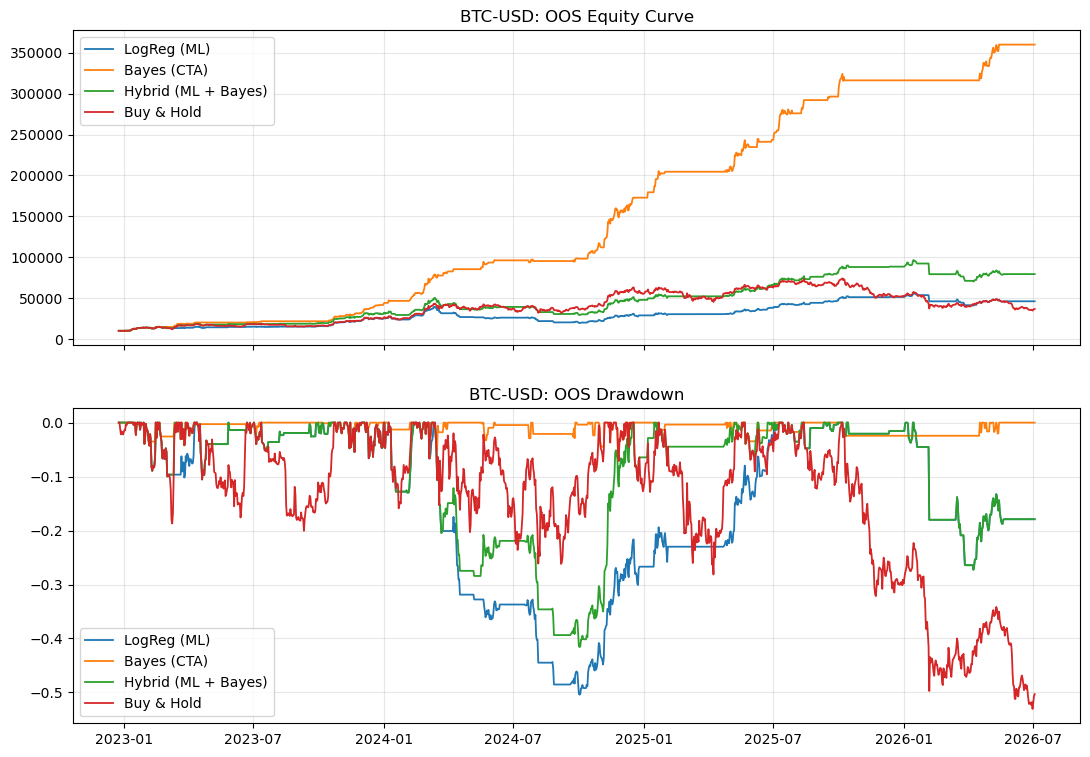


------------------------------------------------------------
ETH-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 0.9251259 | 44.981604 |
| 2         | 0.6103518 | 68.028572 |
| 3         | 1.0429484 | 59.279757 |
| 4         | 1.2351596 | 53.946339 |
| 5         | 0.9033440 | 36.240745 |
| 6         | 1.0602847 | 50.669989 |
| 7         | 1.0012534 | 30.0      |
| 8         | 1.1303196 | 55.993959 |
| 9         | 1.0707010 | 40.708826 |
| 10        | 1.1936002 | 52.761363 |
| 11        | 0.9186656 | 62.361064 |
| 12        | 1.1848681 | 54.446116 |
| 13        | 0.9941231 | 32.833900 |
| 14        | 1.1052237 | 48.103190 |
| 15        | 1.0852043 | 57.531587 |


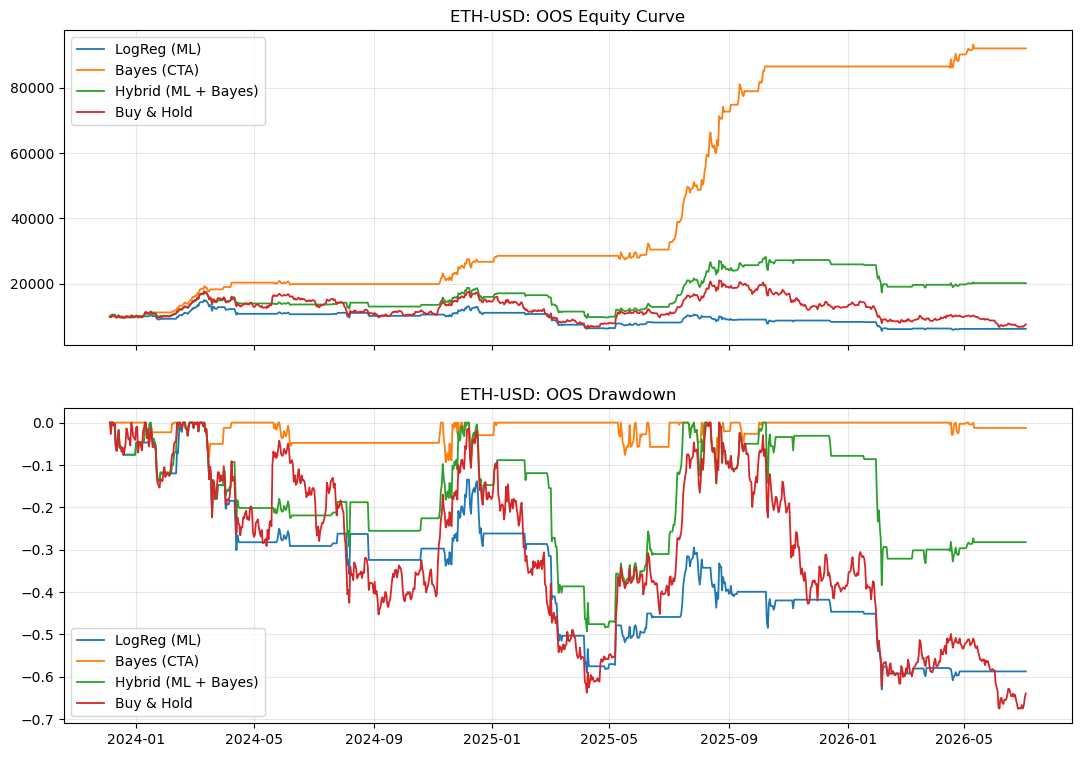


------------------------------------------------------------
SOL-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 1.4369857 | 44.981604 |
| 2         | 1.3167276 | 68.028572 |
| 3         | 1.7854373 | 59.279757 |
| 4         | 1.8027635 | 53.946339 |
| 5         | 1.6339356 | 36.240745 |
| 6         | 1.7070659 | 30.0      |
| 7         | 1.9386128 | 56.569186 |
| 8         | 1.8898478 | 55.685383 |
| 9         | 1.7602096 | 50.229927 |
| 10        | 1.8283977 | 57.535349 |
| 11        | 1.5870895 | 62.314774 |
| 12        | 1.6738074 | 40.070432 |
| 13        | 1.6639416 | 32.894648 |
| 14        | 1.6788337 | 52.079786 |
| 15        | 1.7837942 | 48.301781 |


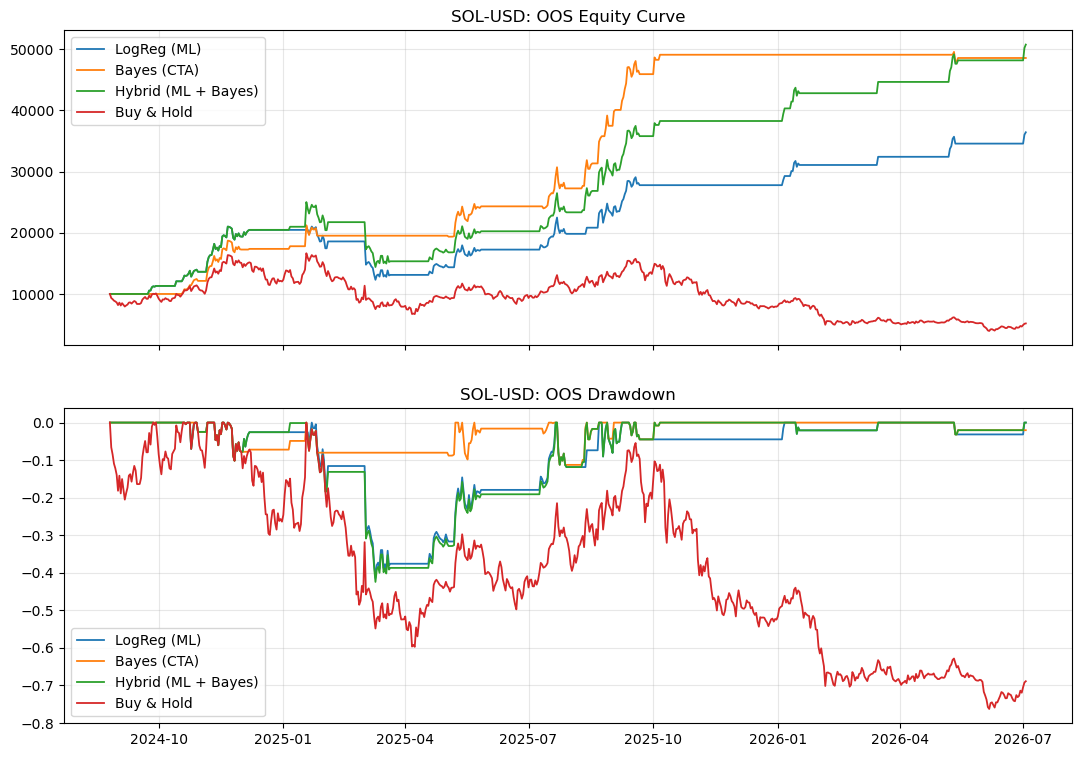


------------------------------------------------------------
BNB-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 1.2301713 | 44.981604 |
| 2         | 1.1607877 | 68.028572 |
| 3         | 1.1017647 | 59.279757 |
| 4         | 1.3333446 | 53.946339 |
| 5         | 1.2282557 | 36.240745 |
| 6         | 1.2301713 | 44.980791 |
| 7         | 1.3073968 | 52.481610 |
| 8         | 1.1261469 | 30.0      |
| 9         | 1.2192104 | 49.128676 |
| 10        | 1.1022339 | 40.550469 |
| 11        | 1.2872237 | 55.520114 |
| 12        | 1.1900777 | 33.794215 |
| 13        | 1.3013734 | 53.392439 |
| 14        | 1.2577281 | 51.109481 |
| 15        | 1.0177126 | 63.939576 |


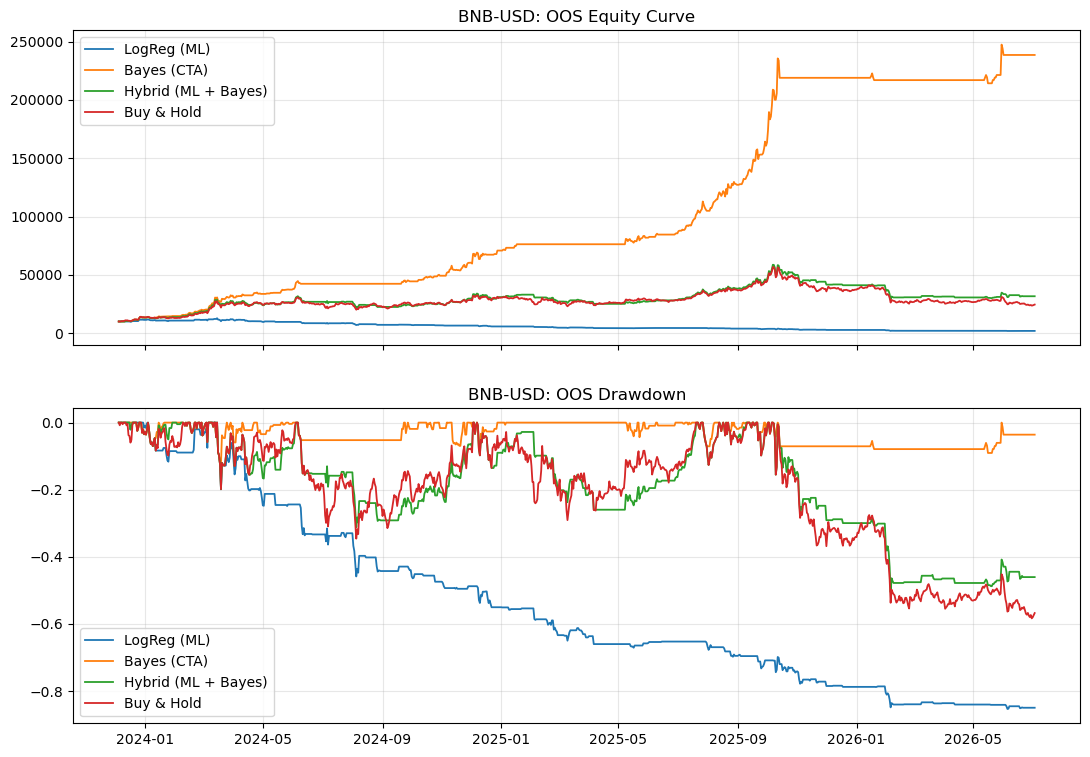

In [6]:
# ==============================================================================
# PART 5: ML DIRECTION PREDICTOR (LOGISTIC REGRESSION + HYBRID ENSEMBLE)
# ==============================================================================

print("\n" + "=" * 80)
print("ML DIRECTION PREDICTOR — LOGISTIC REGRESSION & HYBRID ENSEMBLE")
print("=" * 80)

logreg_preds = {}
logreg_rets = {}
ml_metrics = []

for ticker, safe_asset in zip(TICKERS, SAFE_ASSETS):
    print(f"\n{'-'*60}\n{ticker}")

    # 1. Data Prep
    raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
    close = raw["Close"].iloc[:, 0].dropna() if isinstance(raw.columns, pd.MultiIndex) else raw["Close"].dropna()
    df = build_features(close)

    split_i = int(len(df) * TRAIN_RATIO)
    train, test = df.iloc[:split_i], df.iloc[split_i:]

    # 2. Logistic Regression
    feat_cols = ["Mom5", "Mom20", "RSI14", "EMARatio", "RealVol"]
    scaler = StandardScaler().fit(train[feat_cols].values)
    X_train_s, X_test_s = scaler.transform(train[feat_cols].values), scaler.transform(test[feat_cols].values)

    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    model.fit(X_train_s, train["Target"].values)
    y_pred = model.predict(X_test_s)

    # 3. Bayes & Hybrid Logic
    # Run Bayes Optimization
    best_params = get_bayes_metrics(train, verbose=False)
    bayes_rets  = run_bayes_strategy(test, best_params)
    
    # Calculate Hybrid
    logreg_sig  = (pd.Series(y_pred, index=test.index) > 0.5).astype(int)
    bayes_sig   = (bayes_rets != 0).astype(int)
    hybrid_sig  = ((logreg_sig + bayes_sig) / 2) >= 0.5
    
    # Calculate Returns
    test_bt = test.copy()
    test_bt["DailyRet"] = close.reindex(test.index).pct_change()
    test_bt["LogReg_Ret"] = y_pred.astype(float) * test_bt["DailyRet"]
    test_bt["Bayes_Ret"]  = bayes_rets
    test_bt["Hybrid_Ret"] = hybrid_sig.astype(int) * test_bt["DailyRet"]
    test_bt["BH_Ret"]     = test_bt["DailyRet"]

    # 4. Storage & Metrics
    logreg_preds[ticker] = y_pred
    logreg_rets[ticker]  = test_bt["LogReg_Ret"]

    row = {
        "Ticker": ticker,
        "AUC": f"{roc_auc_score(test['Target'].values, model.predict_proba(X_test_s)[:, 1]):.4f}",
        "LogReg — Sharpe": metrics(test_bt["LogReg_Ret"], "LogReg")["Sharpe"],
        "Bayes — Sharpe":  (bayes_rets.mean() / bayes_rets.std()) * np.sqrt(ANNUALIZATION),
        "Hybrid — Sharpe": (test_bt["Hybrid_Ret"].mean() / test_bt["Hybrid_Ret"].std()) * np.sqrt(ANNUALIZATION)
    }
    ml_metrics.append(row)

    # 5. Professional Plotting
    series = {
        "LogReg (ML)": equity(test_bt["LogReg_Ret"]),
        "Bayes (CTA)": equity(test_bt["Bayes_Ret"]),
        "Hybrid (ML + Bayes)": equity(test_bt["Hybrid_Ret"]),
        "Buy & Hold": equity(test_bt["BH_Ret"])
    }
    
    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
    for lbl, eq_vals in series.items():
        axes[0].plot(test_bt.index, eq_vals, label=lbl, linewidth=1.3)
    axes[0].set_title(f"{ticker}: OOS Equity Curve")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for lbl, eq_vals in series.items():
        axes[1].plot(test_bt.index, drawdown(eq_vals), label=lbl, linewidth=1.3)
    axes[1].set_title(f"{ticker}: OOS Drawdown")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    save_fig(fig, f"Part5_{safe_asset}_oos_equity_drawdown.png")
    test_bt.to_csv(f"{OUTPUT_DIR}/Part5_{safe_asset}_ml_test_timeseries.csv")

# Save Summary
pd.DataFrame(ml_metrics).to_csv(f"{OUTPUT_DIR}/Part5_ml_summary.csv", index=False)

In [7]:
# ==============================================================================
# PART 4b: BACKTEST METRICS TABLE (moved below Part 5)
# This block reads the Part5_*_ml_test_timeseries.csv files, which are written
# by the Part 5 cell below. It must run AFTER Part 5 for the files to exist.
# ==============================================================================
print("\n" + "=" * 80)
print("BACKTEST EVALUATION — LOGREG / BAYES / HYBRID / BUY & HOLD")
print("=" * 80)

all_metrics = []

for ticker, safe_asset in zip(TICKERS, SAFE_ASSETS):
    print(f"Processing {ticker}...")

    # Load OOS ML/Bayes/Hybrid test timeseries from Part 4
    path = f"{OUTPUT_DIR}/Part5_{safe_asset}_ml_test_timeseries.csv"
    if not os.path.exists(path):
        print(f"  Skipping {ticker}: ML test file not found at {path}")
        continue

    df = pd.read_csv(path, parse_dates=["Date"]).set_index("Date").sort_index()

    # Ensure required columns exist
    required_cols = ["LogReg_Ret", "Bayes_Ret", "Hybrid_Ret", "BH_Ret"]
    if not all(c in df.columns for c in required_cols):
        print(f"  Skipping {ticker}: Missing one of {required_cols}")
        continue

    # Build equity curves
    series = {
        "Logistic Regression": equity(df["LogReg_Ret"]),
        "Bayes (CTA Rule)":     equity(df["Bayes_Ret"]),
        "Hybrid (ML + Bayes)":  equity(df["Hybrid_Ret"]),
        "Buy & Hold":           equity(df["BH_Ret"]),
    }

    # Equity + Drawdown charts (OOS only)
    fig = line_chart(df.index, series, f"{ticker}: OOS Equity — All Strategies",
                     f"Equity (${INITIAL_CAP:,.0f} base)")
    save(fig, f"Part4_{safe_asset}_oos_all_equity.png")

    dd_series = {k: drawdown(v) for k, v in series.items()}
    fig = line_chart(df.index, dd_series, f"{ticker}: OOS Drawdown — All Strategies",
                     "Drawdown")
    save(fig, f"Part4_{safe_asset}_oos_all_drawdown.png")

    # Metrics for each strategy (OOS)
    for col, lbl in [
        ("LogReg_Ret",  "Logistic Regression"),
        ("Bayes_Ret",   "Bayes (CTA Rule)"),
        ("Hybrid_Ret",  "Hybrid (ML + Bayes)"),
        ("BH_Ret",      "Buy & Hold"),
    ]:
        m = metrics(df[col], label=lbl)
        m["Asset"]  = ticker
        m["Sample"] = "OOS_TEST_100"
        all_metrics.append(m)

# Assemble metrics table
cols = [
    "Asset", "Sample", "Label", "Days",
    "Total Return", "CAGR", "Ann. Return", "Ann. Vol",
    "Sharpe", "Sortino", "Calmar", "Max DD", "Win Rate",
]
mdf = pd.DataFrame(all_metrics)[cols]

# Display-friendly formatting
disp = mdf.copy()
for c in ["Total Return", "CAGR", "Ann. Return", "Ann. Vol", "Max DD", "Win Rate"]:
    disp[c] = disp[c].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "—")
for c in ["Sharpe", "Sortino", "Calmar"]:
    disp[c] = disp[c].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")

print("\nBACKTEST METRICS — OOS\n" + "=" * 80)
print(disp.to_string(index=False))

mdf.to_csv(f"{OUTPUT_DIR}/Part4_backtest_metrics_all_strategies.csv", index=False)


BACKTEST EVALUATION — LOGREG / BAYES / HYBRID / BUY & HOLD
Processing BTC-USD...
Processing ETH-USD...
Processing SOL-USD...
Processing BNB-USD...

BACKTEST METRICS — OOS
  Asset       Sample               Label  Days Total Return    CAGR Ann. Return Ann. Vol Sharpe Sortino Calmar  Max DD Win Rate
BTC-USD OOS_TEST_100 Logistic Regression  1287      361.11%  54.26%      48.45%   31.89%   1.52    1.57   1.08 -50.42%   52.74%
BTC-USD OOS_TEST_100    Bayes (CTA Rule)  1287     3499.95% 176.30%     105.22%   26.65%   3.95    5.13  24.89  -7.08%   61.43%
BTC-USD OOS_TEST_100 Hybrid (ML + Bayes)  1287      693.49%  79.93%      64.45%   33.75%   1.91    2.10   1.92 -41.60%   53.24%
BTC-USD OOS_TEST_100          Buy & Hold  1287      267.98%  44.70%      47.93%   46.99%   1.02    1.57   0.84 -53.06%   50.00%
ETH-USD OOS_TEST_100 Logistic Regression   942      -37.77% -16.79%      -8.23%   45.20%  -0.18   -0.14  -0.27 -63.01%   50.91%
ETH-USD OOS_TEST_100    Bayes (CTA Rule)   942      819.94% 

## Part 6 — Bayesian Model Evaluation & Comparison

- Reuses the stored CTA market frames and ML outputs to recompute Bayesian‑optimised strategy returns on the test window, reconstruct logistic and hybrid signals, and align all models on a common out‑of‑sample period.  
- Builds a set of comparable return series for four approaches per asset — pure logistic regression, pure Bayes (CTA), hybrid (ML + Bayes), and buy‑and‑hold — then computes annualised Sharpe ratios for each model.  
- Aggregates these results into a tidy comparison table and renders a bar chart of Sharpe ratios by asset and model, providing a clear visual summary of which approach delivers the best risk‑adjusted performance relative to the benchmark.  

Executing automated model evaluation...
--> Processing Analysis for: BTC-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 1.2563172 | 44.981604 |
| 2         | 1.5301504 | 68.028572 |
| 3         | 1.6769682 | 59.279757 |
| 4         | 1.6688069 | 53.946339 |
| 5         | 1.3607561 | 36.240745 |
| 6         | 1.3274533 | 30.0      |
| 7         | 1.7553714 | 56.588528 |
| 8         | 1.7533150 | 57.374541 |
| 9         | 1.7691592 | 56.938056 |
| 10        | 1.6513515 | 63.112004 |
| 11        | 1.6677672 | 50.691856 |
| 12        | 1.3062646 | 40.352887 |
| 13        | 1.6453574 | 65.322000 |
| 14        | 1.6869443 | 52.244350 |
| 15        | 1.6780170 | 61.159141 |
--> Processing Analysis for: ETH-USD
|   iter    |  target   | rsi_entry |
-------------------------------------
| 1         | 0.9018810 | 44.981604 |
| 2         | 0.5580662 | 68.028572 |
| 3         | 0.9162264 | 59.279757 |
| 4         | 1.1168192 | 53.946339 |
| 5         

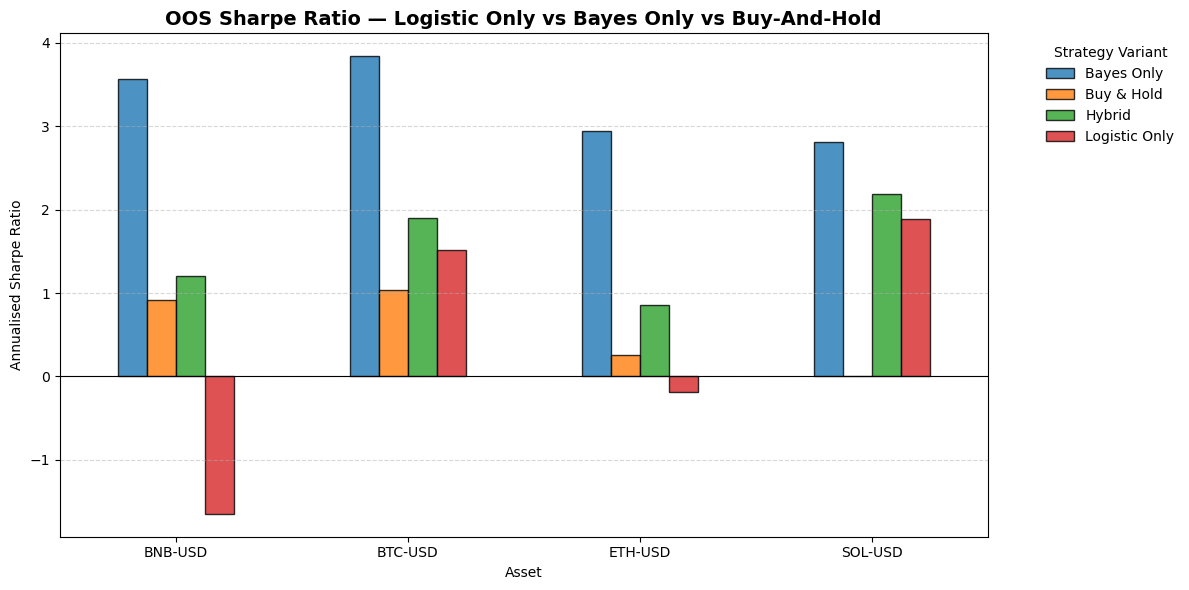

In [8]:
# ==============================================================================
# PART 6: BAYESIAN MODEL EVALUATION & COMPARISON
# ==============================================================================

print("Executing automated model evaluation...")

final_results = []

for asset in TICKERS:
    print(f"--> Processing Analysis for: {asset}")
    safe_asset = asset.replace("-", "_") 
    
    df = market_frames.get(asset)
    if df is None: continue
        
    test_df = df[df['Sample'] == 'TEST'].copy()
    train_df = df[df['Sample'] == 'TRAIN'].copy()
    
    # 1. Bayes signal
    params = get_bayes_metrics(train_df)
    bayes_rets = run_bayes_strategy(test_df, params)
    
    # 2. Hybrid signal
    pred_arr = logreg_preds.get(asset)
    if pred_arr is None: continue
    
    test_bt = pd.read_csv(f"{OUTPUT_DIR}/Part5_{safe_asset}_ml_test_timeseries.csv", 
                          parse_dates=["Date"]).set_index("Date")
    
    logreg_sig = pd.Series(0, index=test_df.index) 
    logreg_sig.loc[test_bt.index] = (pred_arr > 0.5).astype(int)
    
    hybrid_sig = ((logreg_sig + (bayes_rets != 0).astype(int)) / 2) >= 0.5
    hybrid_rets = hybrid_sig.astype(int) * test_df['Close'].pct_change()
    
    # 3. Buy-and-Hold (Benchmark)
    # B&H is always 100% long
    bh_rets = test_df['Close'].pct_change().fillna(0)
    
    # 4. Collect performance
    log_rets = logreg_rets.get(asset)
    
    models = {
        'LogReg': log_rets, 
        'Bayes': bayes_rets, 
        'Hybrid': hybrid_rets,
        'Buy & Hold': bh_rets
    }
    
    for name, rets in models.items():
        if rets is None: continue
        r = pd.Series(rets, index=test_df.index).fillna(0)
        std_dev = r.std()
        sharpe = (r.mean() / std_dev) * np.sqrt(ANNUALIZATION) if std_dev > 0 else 0
        final_results.append({'Asset': asset, 'Model': name, 'Sharpe': sharpe})

# 5. Format and Visualize
comparison_df = pd.DataFrame(final_results).set_index(["Asset", "Model"])

# Optional: relabel models for nicer display
label_map = {
    "LogReg": "Logistic Only",
    "Bayes": "Bayes Only",
    "Hybrid": "Hybrid",
    "Buy & Hold": "Buy & Hold",
}
comparison_df = comparison_df.reset_index()
comparison_df["Model"] = comparison_df["Model"].map(label_map).fillna(comparison_df["Model"])
comparison_df = comparison_df.set_index(["Asset", "Model"])

ax = comparison_df["Sharpe"].unstack().plot(
    kind="bar",
    figsize=(12, 6),
    rot=0,
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("OOS Sharpe Ratio — Logistic Only vs Bayes Only vs Buy-And-Hold", fontsize=14, fontweight="bold")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.axhline(0, color="black", linewidth=0.8)

ax.legend(
    title="Strategy Variant",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Comparison_Impact.png"), bbox_inches="tight", dpi=150)
plt.show()

---

<a id="disclaimer"></a>
## Disclaimer

This notebook is shared for research and educational purposes only. It does not constitute investment advice, and nothing here should be relied on to make trading decisions. Backtested performance does not guarantee future results — the strategies use unrealistic assumptions in places (no slippage/borrow costs, survivorship in the chosen asset list, etc.) that a live implementation would need to address.
